In this notebook the weather data is loaded, analysed and finally added to the taxi dataset.

<!-- From the website <url>https://www.ncei.noaa.gov/access/past-weather/chicago</url>, the weather station at Chicago Midway Airport was selected as it provides the most weather details, including average, max and min temperature as well as precipitation, snowfall and snow depth. Further, different than many airports, the airport is located still within the city boundaries. -->

In [85]:
import pandas as pd
import matplotlib.pyplot as plt

# Open Meteo Weather Data
Following data source provides weather data within chicago at an hourly rate instead of the daily rate provided by the sampling. We take into account that the temperature is different within the city but generally it is expected to change throughout the day more or less evenly. Using a hourly sample rate enables to use day and night temperature influences for later models.

Source:
https://open-meteo.com/en/docs/historical-weather-api?latitude=41.85&longitude=-87.65&hourly=temperature_2m,rain,precipitation,wind_speed_10m,wind_direction_10m,wind_gusts_10m,apparent_temperature,relative_humidity_2m,snow_depth,snowfall&daily=temperature_2m_max,temperature_2m_min&start_date=2024-01-01

In [86]:
import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
	"latitude": 41.85,
	"longitude": -87.65,
	"start_date": "2024-01-01",
	"end_date": "2026-05-11",
	"daily": ["temperature_2m_max", "temperature_2m_min"],
	"hourly": ["temperature_2m", "rain", "precipitation", "wind_speed_10m", "wind_direction_10m", "wind_gusts_10m", "apparent_temperature", "relative_humidity_2m", "snow_depth", "snowfall"],
	"timezone": "America/Chicago",
}
responses = openmeteo.weather_api(url, params = params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone: {response.Timezone()}{response.TimezoneAbbreviation()}")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Process hourly data. The order of variables needs to be the same as requested.
hourly = response.Hourly()
hourly_temperature_2m = hourly.Variables(0).ValuesAsNumpy()
hourly_rain = hourly.Variables(1).ValuesAsNumpy()
hourly_precipitation = hourly.Variables(2).ValuesAsNumpy()
hourly_wind_speed_10m = hourly.Variables(3).ValuesAsNumpy()
hourly_wind_direction_10m = hourly.Variables(4).ValuesAsNumpy()
hourly_wind_gusts_10m = hourly.Variables(5).ValuesAsNumpy()
hourly_apparent_temperature = hourly.Variables(6).ValuesAsNumpy()
hourly_relative_humidity_2m = hourly.Variables(7).ValuesAsNumpy()
hourly_snow_depth = hourly.Variables(8).ValuesAsNumpy()
hourly_snowfall = hourly.Variables(9).ValuesAsNumpy()

hourly_data = {
	"date": pd.date_range(
		start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
		end =  pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
		freq = pd.Timedelta(seconds = hourly.Interval()),
		inclusive = "left"
	).tz_convert(response.Timezone().decode())
}

hourly_data["temperature_2m"] = hourly_temperature_2m
hourly_data["rain"] = hourly_rain
hourly_data["precipitation"] = hourly_precipitation
hourly_data["wind_speed_10m"] = hourly_wind_speed_10m
hourly_data["wind_direction_10m"] = hourly_wind_direction_10m
hourly_data["wind_gusts_10m"] = hourly_wind_gusts_10m
hourly_data["apparent_temperature"] = hourly_apparent_temperature
hourly_data["relative_humidity_2m"] = hourly_relative_humidity_2m
hourly_data["snow_depth"] = hourly_snow_depth
hourly_data["snowfall"] = hourly_snowfall

hourly_dataframe = pd.DataFrame(data = hourly_data)
print("\nHourly data:\n")
display(hourly_dataframe)

# Process daily data. The order of variables needs to be the same as requested.
daily = response.Daily()
daily_temperature_2m_max = daily.Variables(0).ValuesAsNumpy()
daily_temperature_2m_min = daily.Variables(1).ValuesAsNumpy()

daily_data = {
	"date": pd.date_range(
		start = pd.to_datetime(daily.Time(), unit = "s", utc = True),
		end =  pd.to_datetime(daily.TimeEnd(), unit = "s", utc = True),
		freq = pd.Timedelta(seconds = daily.Interval()),
		inclusive = "left"
	).tz_convert(response.Timezone().decode()).normalize()
}

daily_data["temperature_2m_max"] = daily_temperature_2m_max
daily_data["temperature_2m_min"] = daily_temperature_2m_min

daily_dataframe = pd.DataFrame(data = daily_data)
print("\nDaily data:")
display(daily_dataframe)


Coordinates: 41.8629150390625°N -87.64877319335938°E
Elevation: 179.0 m asl
Timezone: b'America/Chicago'b'GMT-5'
Timezone difference to GMT+0: -18000s

Hourly data:



,date,temperature_2m,rain,precipitation,wind_speed_10m,wind_direction_10m,wind_gusts_10m,apparent_temperature,relative_humidity_2m,snow_depth,snowfall
0,2023-12-31 23:00:00-06:00,0.55,0.0,0.1,30.449274,335.556061,45.719997,-6.270780,84.567177,0.01,0.07
1,2024-01-01 00:00:00-06:00,0.35,0.0,0.1,30.449274,335.556061,44.279999,-6.484540,85.168861,0.01,0.07
2,2024-01-01 01:00:00-06:00,0.50,0.0,0.1,30.068083,343.300690,44.639996,-6.244465,85.814316,0.01,0.07
3,2024-01-01 02:00:00-06:00,0.75,0.0,0.1,27.766712,346.504242,43.560001,-5.637848,85.213921,0.01,0.07
4,2024-01-01 03:00:00-06:00,0.55,0.0,0.0,25.417631,344.388947,39.959999,-5.523197,85.191414,0.01,0.00
...,...,...,...,...,...,...,...,...,...,...,...
20683,2026-05-11 19:00:00-05:00,8.65,0.0,0.0,11.207801,29.858927,29.879999,4.699236,49.633121,0.00,0.00
20684,2026-05-11 20:00:00-05:00,7.40,0.0,0.0,9.511088,29.475794,28.080000,3.732326,55.031811,0.00,0.00
20685,2026-05-11 21:00:00-05:00,7.15,0.0,0.0,7.848083,36.607166,22.680000,3.827988,58.912880,0.00,0.00
20686,2026-05-11 22:00:00-05:00,7.00,0.0,0.0,5.740279,48.814175,18.719999,4.101182,62.847366,0.00,0.00



Daily data:


,date,temperature_2m_max,temperature_2m_min
0,2023-12-31 00:00:00-06:00,1.350000,-2.60
1,2024-01-01 00:00:00-06:00,2.500000,-4.60
2,2024-01-02 00:00:00-06:00,2.050000,-1.45
3,2024-01-03 00:00:00-06:00,1.000000,-4.60
4,2024-01-04 00:00:00-06:00,2.100000,-5.40
...,...,...,...
857,2026-05-07 00:00:00-05:00,15.450000,3.50
858,2026-05-08 00:00:00-05:00,16.299999,6.75
859,2026-05-09 00:00:00-05:00,23.850000,10.85
860,2026-05-10 00:00:00-05:00,15.100000,7.50


## Plot daily weather data to find gaps

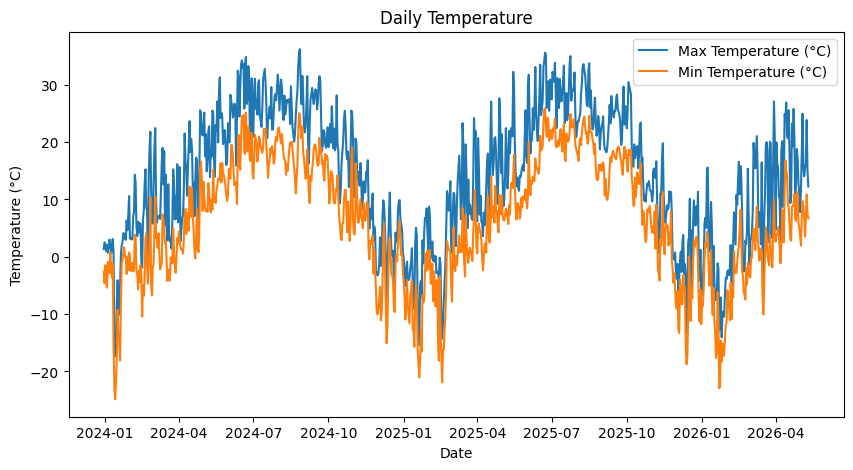

In [87]:
# plot daily weather data
plt.figure(figsize = (10, 5))
plt.plot(daily_dataframe["date"], daily_dataframe["temperature_2m_max"], label = "Max Temperature (°C)")
plt.plot(daily_dataframe["date"], daily_dataframe["temperature_2m_min"], label = "Min Temperature (°C)")
plt.title("Daily Temperature")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.show()

## Merge daily into hourly data set

In [88]:
hourly_for_merge = hourly_dataframe.copy()
hourly_for_merge["date_day"] = hourly_for_merge["date"].dt.strftime("%Y-%m-%d")

daily_for_merge = daily_dataframe.copy()
daily_for_merge["date_day"] = daily_for_merge["date"].dt.strftime("%Y-%m-%d")

weather_data = hourly_for_merge.merge(
    daily_for_merge.drop(columns=["date"]),
    on="date_day",
    how="left"
).drop(columns=["date_day"])

display(weather_data.head())

,date,temperature_2m,rain,precipitation,wind_speed_10m,wind_direction_10m,wind_gusts_10m,apparent_temperature,relative_humidity_2m,snow_depth,snowfall,temperature_2m_max,temperature_2m_min
0,2023-12-31 23:00:00-06:00,0.55,0.0,0.1,30.449274,335.556061,45.719997,-6.270780,84.567177,0.01,0.07,1.35,-2.6
1,2024-01-01 00:00:00-06:00,0.35,0.0,0.1,30.449274,335.556061,44.279999,-6.484540,85.168861,0.01,0.07,2.50,-4.6
2,2024-01-01 01:00:00-06:00,0.50,0.0,0.1,30.068083,343.300690,44.639996,-6.244465,85.814316,0.01,0.07,2.50,-4.6
3,2024-01-01 02:00:00-06:00,0.75,0.0,0.1,27.766712,346.504242,43.560001,-5.637848,85.213921,0.01,0.07,2.50,-4.6
4,2024-01-01 03:00:00-06:00,0.55,0.0,0.0,25.417631,344.388947,39.959999,-5.523197,85.191414,0.01,0.00,2.50,-4.6


In [89]:
# get 2026-05-11 all records
record_2026_05_11 = weather_data[weather_data["date"] > "2026-05-10 23:00:00"]
record_2026_05_11

,date,temperature_2m,rain,precipitation,wind_speed_10m,wind_direction_10m,wind_gusts_10m,apparent_temperature,relative_humidity_2m,snow_depth,snowfall,temperature_2m_max,temperature_2m_min
20714,2026-05-11 00:00:00-05:00,12.25,0.0,0.0,9.505977,161.221878,19.440001,8.858130,45.316113,0.0,0.0,12.25,6.7
20715,2026-05-11 01:00:00-05:00,11.30,0.0,0.0,8.258451,159.590027,20.160000,8.248513,51.652565,0.0,0.0,12.25,6.7
20716,2026-05-11 02:00:00-05:00,9.80,0.0,0.0,2.367530,171.253922,16.919998,7.757664,60.644794,0.0,0.0,12.25,6.7
20717,2026-05-11 03:00:00-05:00,9.90,0.0,0.0,5.072041,27.474344,9.720000,7.738462,66.733795,0.0,0.0,12.25,6.7
20718,2026-05-11 04:00:00-05:00,8.40,0.0,0.0,13.902015,41.325405,29.879999,5.197957,80.283241,0.0,0.0,12.25,6.7
20719,2026-05-11 05:00:00-05:00,6.95,0.0,0.0,13.022349,40.515305,31.319998,3.699067,83.519997,0.0,0.0,12.25,6.7
20720,2026-05-11 06:00:00-05:00,6.70,0.0,0.0,13.184308,32.171192,29.160000,3.345276,82.615494,0.0,0.0,12.25,6.7
20721,2026-05-11 07:00:00-05:00,7.80,0.0,0.0,14.658676,24.676849,35.639999,4.250235,77.169113,0.0,0.0,12.25,6.7
20722,2026-05-11 08:00:00-05:00,8.65,0.0,0.0,15.376045,27.164909,37.799999,4.840287,68.855934,0.0,0.0,12.25,6.7
20723,2026-05-11 09:00:00-05:00,9.35,0.0,0.0,17.161469,24.145542,42.119999,5.159282,62.726921,0.0,0.0,12.25,6.7


## Plot all features over time

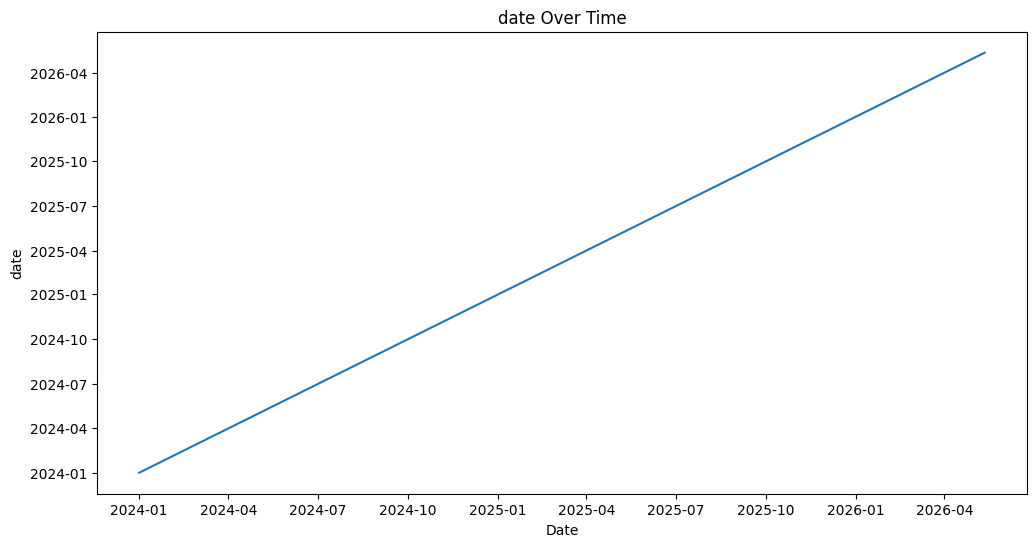

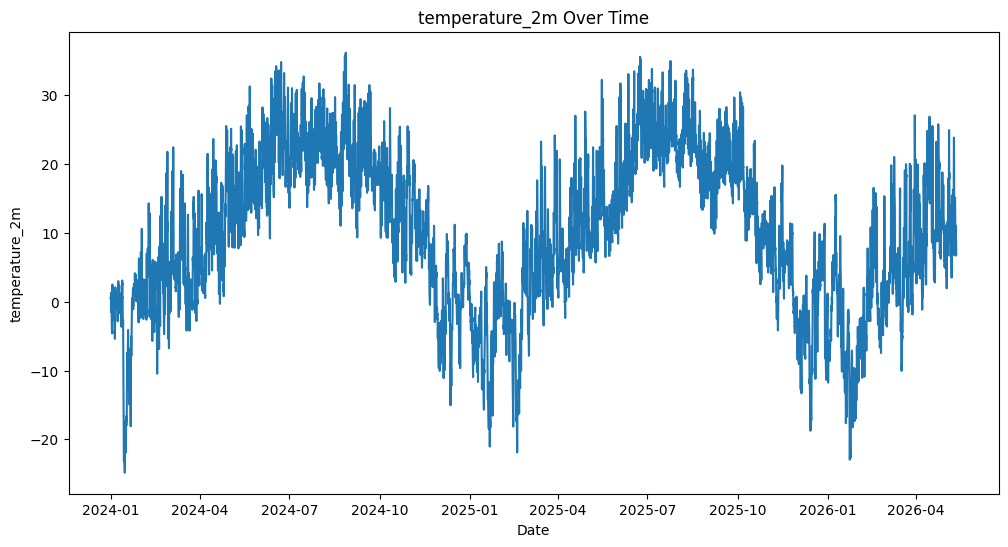

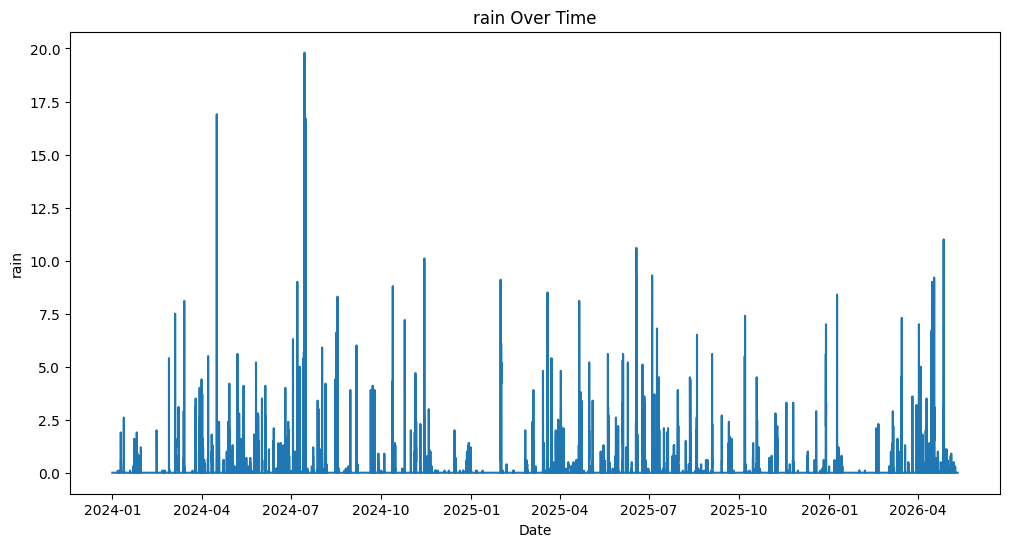

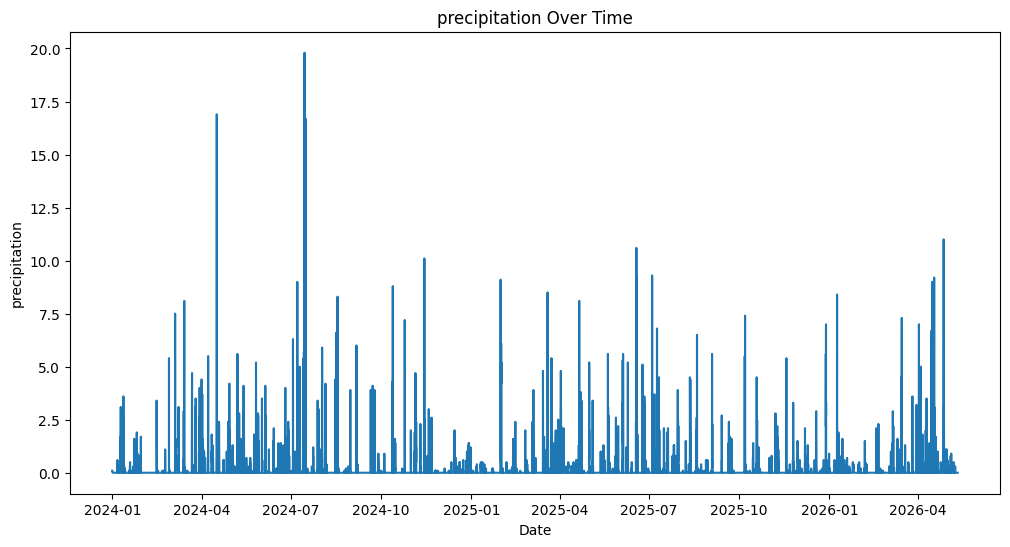

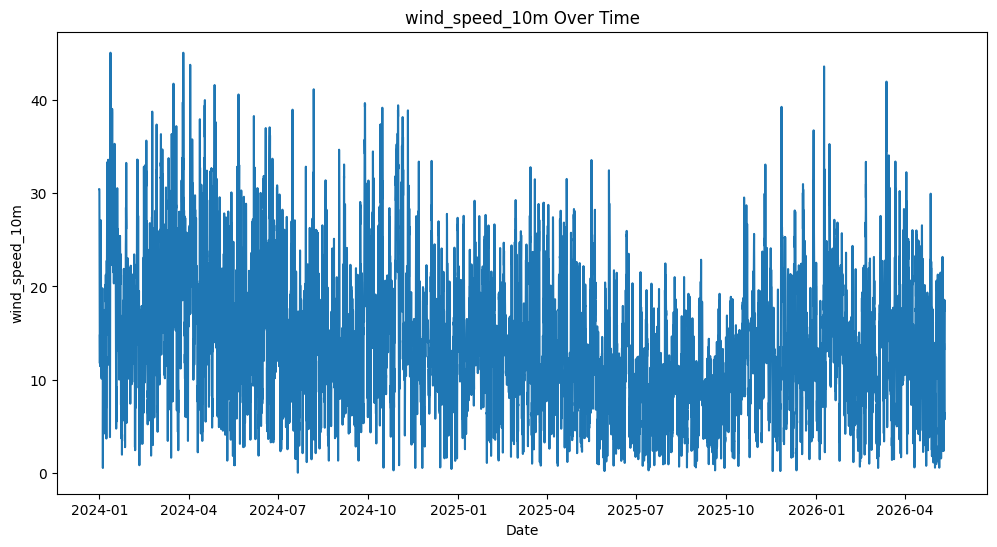

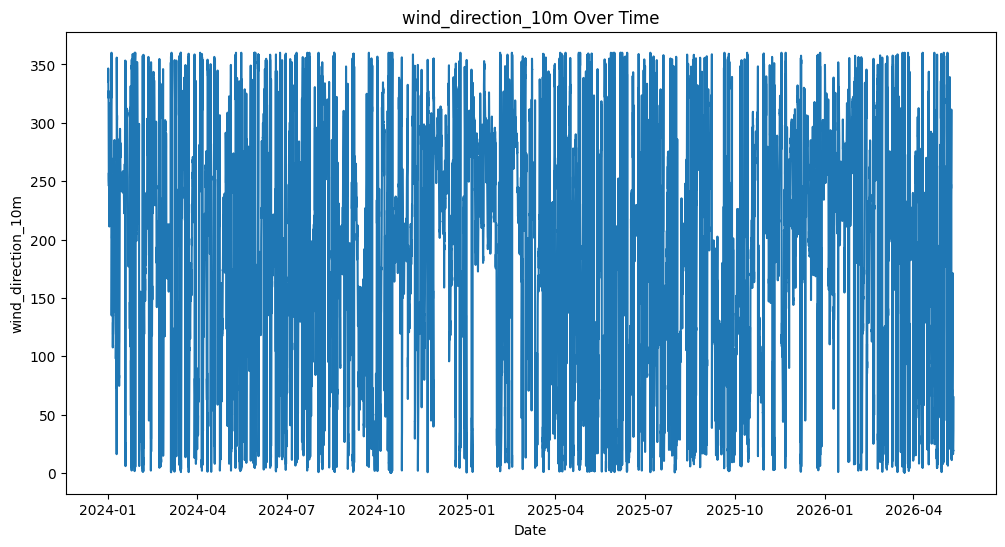

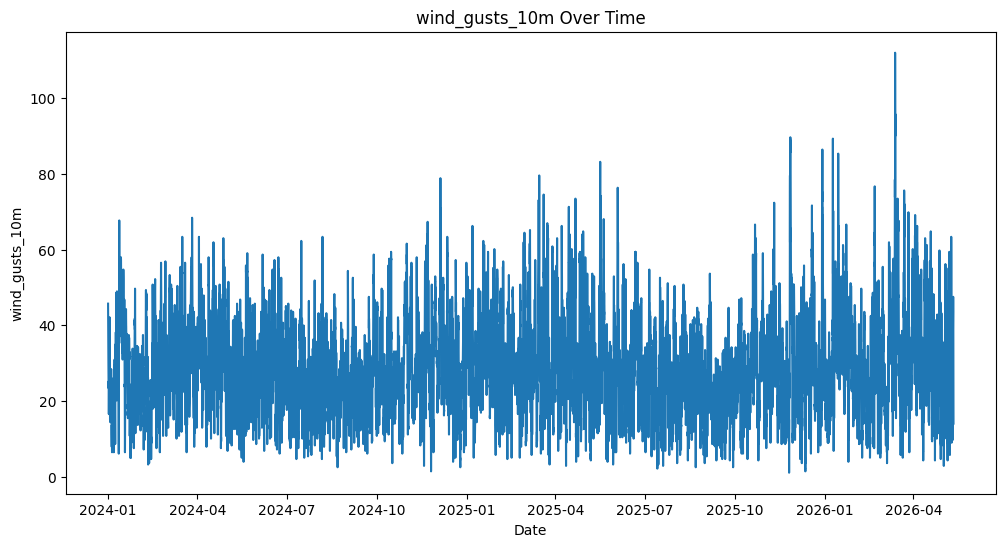

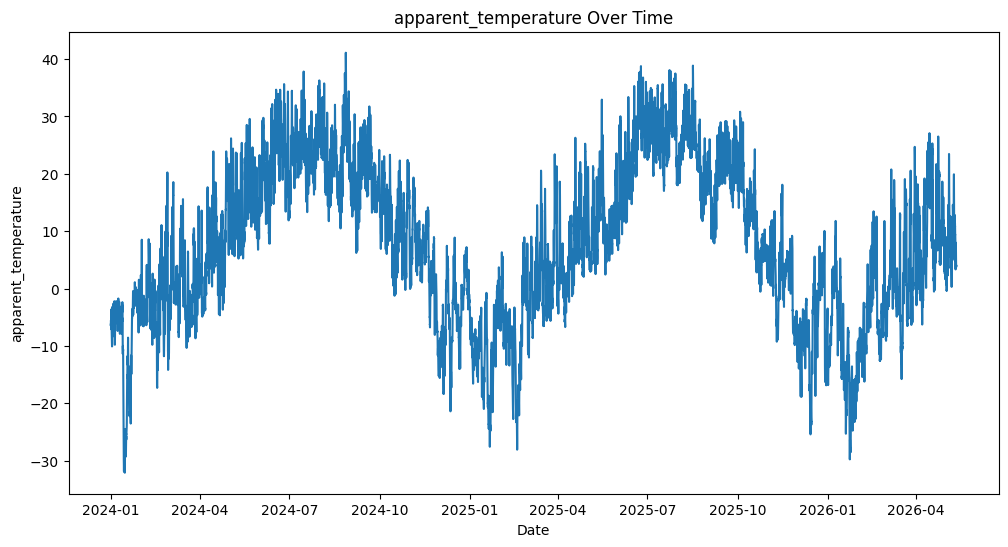

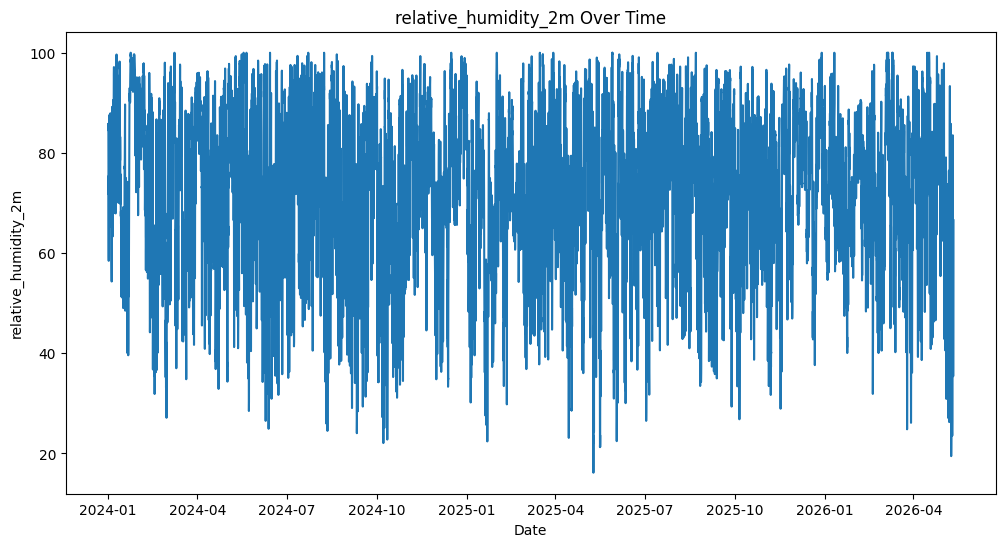

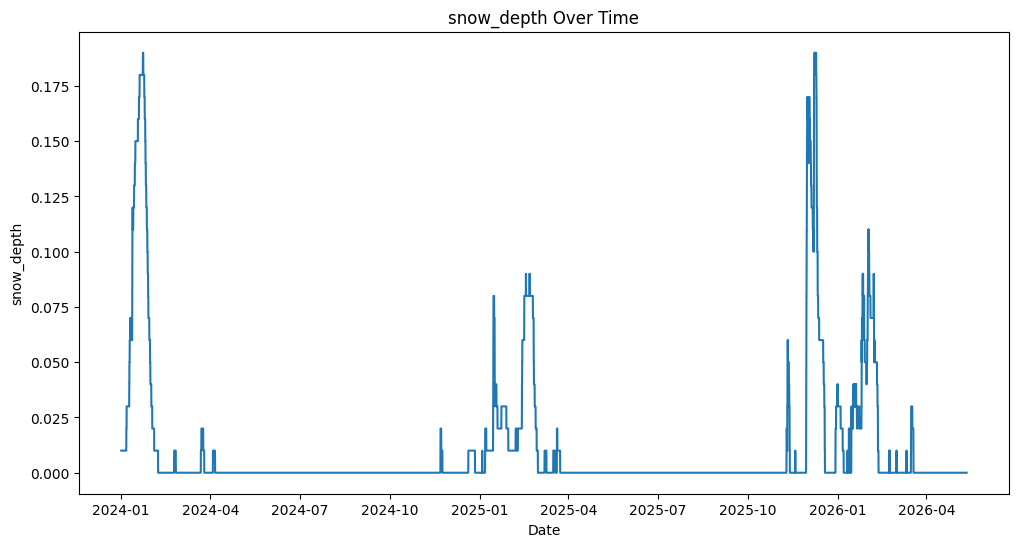

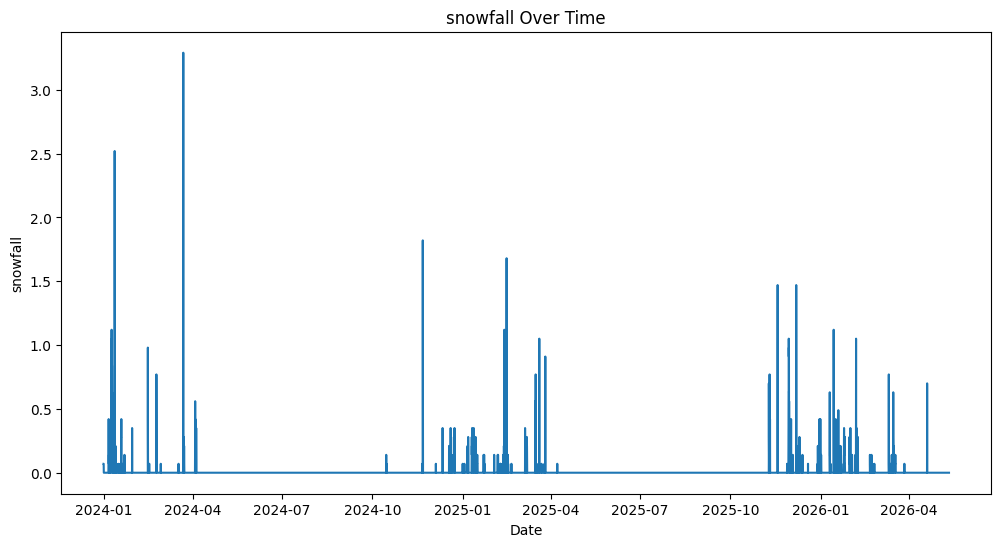

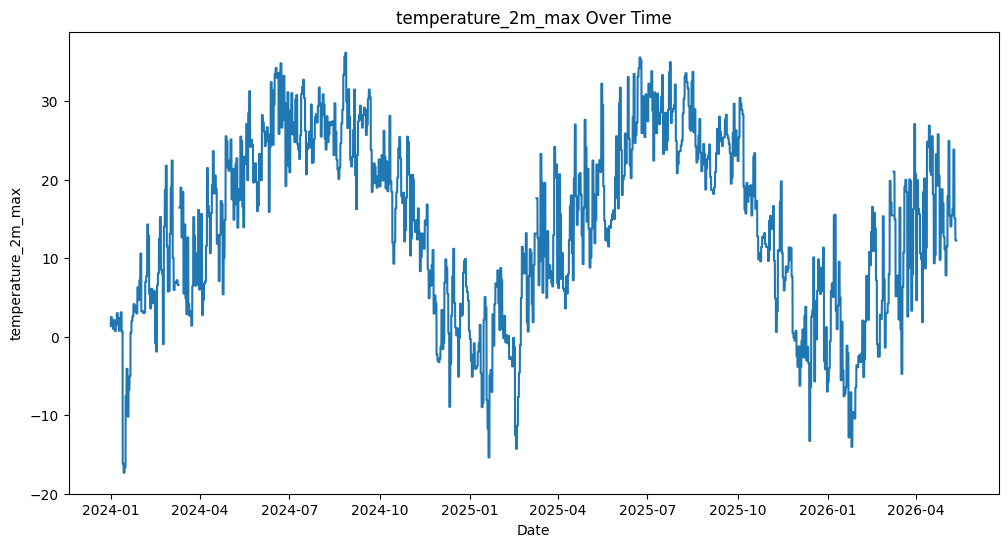

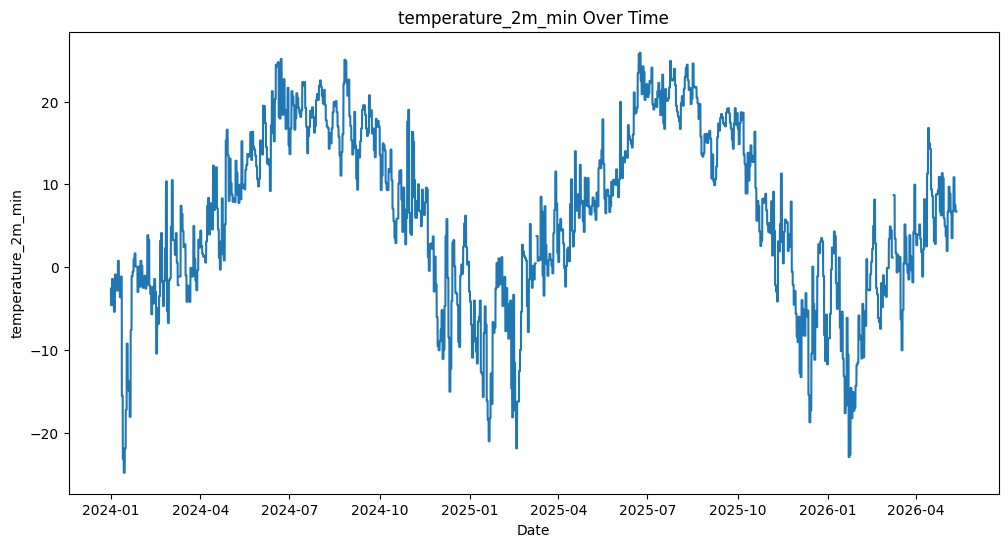

In [90]:
# feature over time
for column in weather_data.columns:
    plt.figure(figsize=(12, 6))
    plt.plot(weather_data['date'], weather_data[column])
    plt.xlabel('Date')
    plt.ylabel(column)
    plt.title(f'{column} Over Time')
    plt.show()

## Analysis of missing data in weather data
The weather data has only a few missing values. Around 69 values are missing from the daily min max values.

In [91]:
weather_data.info()
print("\nNumber of incomplete records:", len(weather_data[weather_data.isnull().any(axis=1)]))

<class 'pandas.DataFrame'>
RangeIndex: 20738 entries, 0 to 20737
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype                         
---  ------                --------------  -----                         
 0   date                  20738 non-null  datetime64[s, America/Chicago]
 1   temperature_2m        20738 non-null  float32                       
 2   rain                  20738 non-null  float32                       
 3   precipitation         20738 non-null  float32                       
 4   wind_speed_10m        20738 non-null  float32                       
 5   wind_direction_10m    20738 non-null  float32                       
 6   wind_gusts_10m        20738 non-null  float32                       
 7   apparent_temperature  20738 non-null  float32                       
 8   relative_humidity_2m  20738 non-null  float32                       
 9   snow_depth            20738 non-null  float32                       
 10  snowfall 

Below test shows that the 69 records are always missing both column values, for the daily min and max temperature values.

In [92]:
incomplete_weather_records = weather_data[weather_data['temperature_2m_max'].isnull() & weather_data['temperature_2m_min'].isnull()]
print('Number of records missing both, min and max temperature:', len(incomplete_weather_records.index))

Number of records missing both, min and max temperature: 69


In total three days are affected by this. One need to check later how many taxi trips this will affect.

In [93]:
incomplete_weather_records.groupby(incomplete_weather_records['date'].dt.date).size()

date
2024-03-10    23
2025-03-09    23
2026-03-08    23
dtype: int64

# Merge with taxi data
We are merging the the two nearest data records together using pandas.merge_asof. This allows us to ignore missing values as if the record is missing we just select the next closest one.

In [94]:
taxi_data = pd.read_csv("../data/example_data.csv")
taxi_data['trip_start_timestamp'] = pd.to_datetime(taxi_data['trip_start_timestamp'], utc=True).dt.tz_convert('America/Chicago').astype('datetime64[s, America/Chicago]')
taxi_data['trip_end_timestamp'] = pd.to_datetime(taxi_data['trip_end_timestamp'], utc=True).dt.tz_convert('America/Chicago').astype('datetime64[s, America/Chicago]')
display(taxi_data.head())

,trip_id,taxi_id,trip_start_timestamp,trip_end_timestamp,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,...,extras,trip_total,payment_type,company,pickup_centroid_latitude,pickup_centroid_longitude,pickup_centroid_location,dropoff_centroid_latitude,dropoff_centroid_longitude,dropoff_centroid_location
0,6ed9af5d9c52fdf5535fb38b760bc0bae8a5bd51,e3231f11a2e775788c4bcc58852ae4d4e3b2d78e8a2cb4...,2026-04-30 19:00:00-05:00,2026-04-30 19:30:00-05:00,1672,18.25,NaN,NaN,76.0,28.0,...,4.0,60.00,Credit Card,Sun Taxi,41.980264,-87.913625,POINT (-87.913624596 41.9802643146),41.874005,-87.663518,POINT (-87.6635175498 41.874005383)
1,c107c04a1b74fa964072ae605bca82d9aa76d2eb,38d00610debf2306201a33902c298ea78df627880d3d19...,2026-04-30 19:00:00-05:00,2026-04-30 19:00:00-05:00,399,1.38,NaN,NaN,8.0,8.0,...,0.0,6.75,Cash,Flash Cab,41.899602,-87.633308,POINT (-87.6333080367 41.899602111),41.899602,-87.633308,POINT (-87.6333080367 41.899602111)
2,497b50a57cb828b7d2b8f4cff0e09394fdb539ec,b972ec70e50b0f04e4fa382c61337d527d0cdfcf2c3007...,2026-04-30 19:00:00-05:00,2026-04-30 19:00:00-05:00,600,1.70,NaN,NaN,28.0,8.0,...,0.0,10.75,Credit Card,Transit Administrative Center Inc,41.874005,-87.663518,POINT (-87.6635175498 41.874005383),41.899602,-87.633308,POINT (-87.6333080367 41.899602111)
3,f48c3b6c5c3bb929f585a167a9fd1f7280eafaf2,85c39e068db414d181c6252a89fd822afc2e169a9a9e85...,2026-04-30 19:00:00-05:00,2026-04-30 19:00:00-05:00,398,1.16,NaN,NaN,32.0,8.0,...,1.0,10.25,Credit Card,Blue Ribbon Taxi Association,41.878866,-87.625192,POINT (-87.6251921424 41.8788655841),41.899602,-87.633308,POINT (-87.6333080367 41.899602111)
4,14272d1dedb28d0954d3fff687788f379e0eabf7,2bb3cec6c1f7c3ea064aff56988b02be67da8f90a02af8...,2026-04-30 19:00:00-05:00,2026-04-30 19:15:00-05:00,1632,18.59,NaN,NaN,76.0,8.0,...,4.0,60.90,Credit Card,Sun Taxi,41.980264,-87.913625,POINT (-87.913624596 41.9802643146),41.899602,-87.633308,POINT (-87.6333080367 41.899602111)


In [95]:
taxi_data.dtypes

trip_id                                                  str
taxi_id                                                  str
trip_start_timestamp          datetime64[s, America/Chicago]
trip_end_timestamp            datetime64[s, America/Chicago]
trip_seconds                                           int64
trip_miles                                           float64
pickup_census_tract                                  float64
dropoff_census_tract                                 float64
pickup_community_area                                float64
dropoff_community_area                               float64
fare                                                 float64
tips                                                 float64
tolls                                                float64
extras                                               float64
trip_total                                           float64
payment_type                                             str
company                 

In [96]:
weather_data.dtypes

date                    datetime64[s, America/Chicago]
temperature_2m                                 float32
rain                                           float32
precipitation                                  float32
wind_speed_10m                                 float32
wind_direction_10m                             float32
wind_gusts_10m                                 float32
apparent_temperature                           float32
relative_humidity_2m                           float32
snow_depth                                     float32
snowfall                                       float32
temperature_2m_max                             float32
temperature_2m_min                             float32
dtype: object

Relevant are the two timestamp columns for the merger. We can merge the data twice, once on the trip start and trip end.

In [97]:
taxi_data = taxi_data.sort_values('trip_start_timestamp')
weather_data = weather_data.sort_values('date')

merged_data = pd.merge_asof(
    taxi_data,
    weather_data,
    left_on='trip_start_timestamp',
    right_on='date',
    direction='nearest' 
)

merged_data['delta_time'] = (merged_data['trip_start_timestamp'] - merged_data['date']).abs()
avg_min_diff = merged_data['delta_time'].min()


print(f"Minimum time difference: {avg_min_diff}")
avg_max_diff = merged_data['delta_time'].max()
print(f"Maximum time difference: {avg_max_diff}")
avg_diff = merged_data['delta_time'].mean()
print(f"Average time difference: {avg_diff}")

Minimum time difference: 0 days 00:00:00
Maximum time difference: 0 days 00:30:00
Average time difference: 0 days 00:16:35


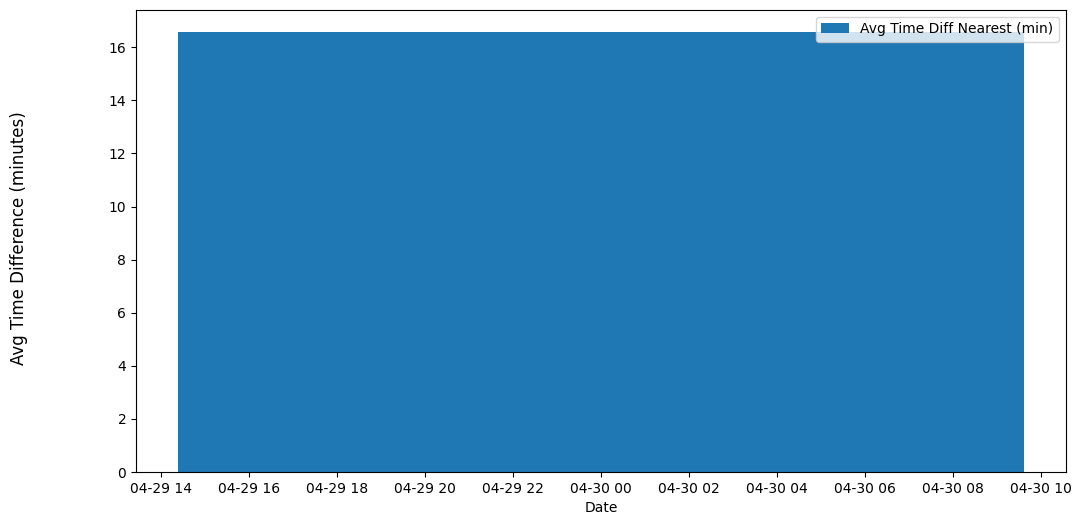

In [98]:

# TODO check the plot with the full dataset later as it should show more variation
merged_data['delta_time_minutes'] = merged_data['delta_time']/ pd.Timedelta(minutes=1)
fig, ax = plt.subplots(1,1, figsize=(12, 6), sharex=True)
plt_merged_data = merged_data.groupby(merged_data['trip_start_timestamp'].dt.date)['delta_time_minutes'].mean()

ax.bar(plt_merged_data.index, plt_merged_data.values, label='Avg Time Diff Nearest (min)')

fig.supylabel('Avg Time Difference (minutes)')

ax.legend()
ax.ticklabel_format(style='plain', axis='y')
ax.set_xlabel('Date')
plt.show()

Minimum time difference: 0 days 00:00:00
Maximum time difference: 0 days 00:30:00
Average time difference: 0 days 00:14:59


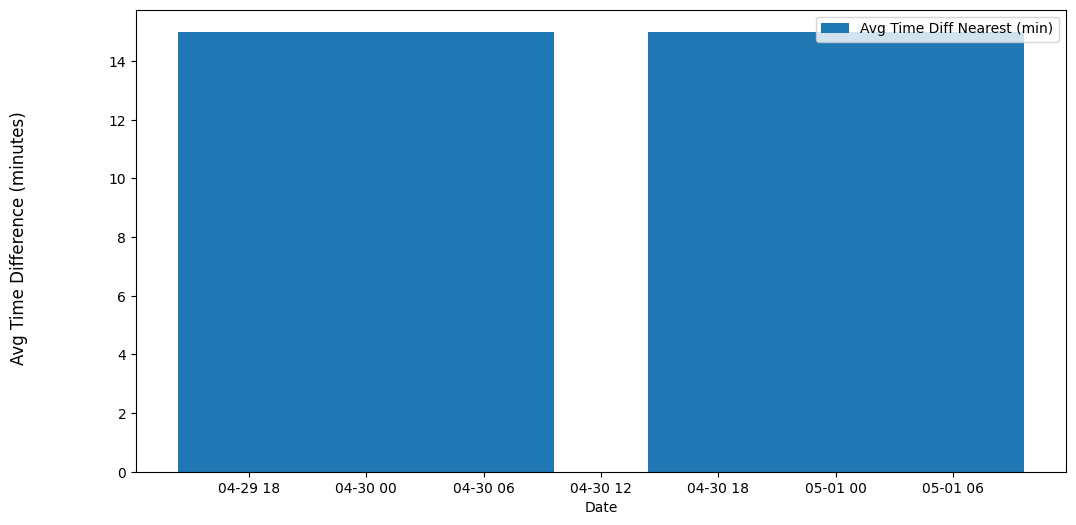

In [99]:
taxi_data = taxi_data.sort_values('trip_end_timestamp')
weather_data = weather_data.sort_values('date')

merged_data = pd.merge_asof(
    taxi_data,
    weather_data,
    left_on='trip_end_timestamp',
    right_on='date',
    direction='nearest' 
)

merged_data['delta_time'] = (merged_data['trip_end_timestamp'] - merged_data['date']).abs()
avg_min_diff = merged_data['delta_time'].min()


print(f"Minimum time difference: {avg_min_diff}")
avg_max_diff = merged_data['delta_time'].max()
print(f"Maximum time difference: {avg_max_diff}")
avg_diff = merged_data['delta_time'].mean()
print(f"Average time difference: {avg_diff}")


# TODO check the plot with the full dataset later as it should show more variation
merged_data['delta_time_minutes'] = merged_data['delta_time']/ pd.Timedelta(minutes=1)
fig, ax = plt.subplots(1,1, figsize=(12, 6), sharex=True)
plt_merged_data = merged_data.groupby(merged_data['trip_end_timestamp'].dt.date)['delta_time_minutes'].mean()

ax.bar(plt_merged_data.index, plt_merged_data.values, label='Avg Time Diff Nearest (min)')

fig.supylabel('Avg Time Difference (minutes)')

ax.legend()
ax.ticklabel_format(style='plain', axis='y')
ax.set_xlabel('Date')
plt.show()